coefficients (degree 2): [ 5.06875496  0.03867823 -0.01081788]
NumPy lstsq coefficients: [ 5.06875496  0.03867823 -0.01081788]

Original line: y = 4.000x + 5.000
coefficients (linear): [5.51048713 4.02222186]
NumPy lstsq coefficients: [5.51048713 4.02222186]
Largest residual: 0.469 at x = 0.850
Smallest residual: -0.511 at x = 0.900


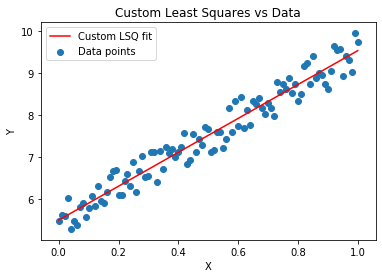

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def least_squares(x, y, degree):
    # design matrix A
    A = np.vstack([x**i for i in range(degree+1)]).T
    # calculate coefficients 
    coeffs = np.linalg.inv(A.T @ A) @ A.T @ y
    return coeffs

# my own least squares

X = np.random.rand(100) * 10
x = np.sort(X)
y = np.random.rand(100) * 10

# degree 2 least squares
results = least_squares(x, y, 2)
print("coefficients (degree 2):", results)

# NumPy least squares
A_np = np.vstack([x**i for i in range(3)]).T  # degree=2
np_coeffs, residuals, rank, s = np.linalg.lstsq(A_np, y, rcond=None)
print("NumPy lstsq coefficients:", np_coeffs)


# my own function with random error

m = 4
b = 5
print("\nOriginal line: y = {:.3f}x + {:.3f}".format(m, b))

# X from 0 to 1 in steps of 0.01
x1 = np.arange(0, 1.01, 0.01)

# Y = mx + b +/- random noise in [0,1)
y1 = m*x1 + b + np.random.rand(len(x1))

# Fit with custom least squares
results1 = least_squares(x1, y1, 1)
print("coefficients (linear):", results1)

# Fit with NumPy lstsq
A1 = np.vstack([x1**i for i in range(2)]).T  # linear fit
np_results1, residuals1, rank1, s1 = np.linalg.lstsq(A1, y1, rcond=None)
print("NumPy lstsq coefficients:", np_results1)

# Predicted Y
y_pred = results1[0] + results1[1]*x1

# Residuals
residuals = y1 - y_pred
max_res_idx = np.argmax(residuals)
min_res_idx = np.argmin(residuals)
print("Largest residual: {:.3f} at x = {:.3f}".format(residuals[max_res_idx], x1[max_res_idx]))
print("Smallest residual: {:.3f} at x = {:.3f}".format(residuals[min_res_idx], x1[min_res_idx]))

# plot
plt.scatter(x1, y1, label="Data points")
plt.plot(x1, y_pred, color="red", label="Custom LSQ fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Custom Least Squares vs Data")
plt.legend()
plt.show()